In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [29]:
# NSL-KDD columns
with open("feature_names.txt") as f:
    cols = [line.strip() for line in f]

# Load data
train = pd.read_csv("KDDTrain+.txt", names=cols)
test = pd.read_csv("KDDTest+.txt", names=cols)

# Verify dataset dimensions
assert train.shape[1] == 43
assert test.shape[1] == 43

print("Training set shape:", train.shape)
print("Test set shape:", test.shape)


Training set shape: (125973, 43)
Test set shape: (22544, 43)


In [30]:
def load_data():

    with open("feature_names.txt") as f:
        cols = [line.strip() for line in f]

    train = pd.read_csv("KDDTrain+.txt", names=cols)
    test = pd.read_csv("KDDTest+.txt", names=cols)

    train['label'] = train['label'].apply(
        lambda x: 0 if str(x).strip().startswith("normal") else 1
    )

    test['label'] = test['label'].apply(
        lambda x: 0 if str(x).strip().startswith("normal") else 1
    )

    for col in ['protocol_type','service','flag']:

        le = LabelEncoder()

        allvals = pd.concat([train[col], test[col]])

        le.fit(allvals)

        train[col] = le.transform(train[col])
        test[col] = le.transform(test[col])

    return train, test

train, test = load_data()

In [31]:
def prepare_data(train, test):

    X_train = train.drop(['label','difficulty'], axis=1)
    y_train = train['label']

    X_test = test.drop(['label','difficulty'], axis=1)
    y_test = test['label']

    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = prepare_data(train,test)

In [32]:
def train_random_forest(X_train,y_train):

    model_rf = RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=42
    )

    model_rf.fit(X_train,y_train)

    return model_rf

model_rf = train_random_forest(X_train,y_train)

pred_rf = model_rf.predict(X_test)

In [33]:
def train_logistic_regression(X_train,
                              X_test,
                              y_train):

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    model_lr = LogisticRegression(
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    )

    model_lr.fit(X_train_scaled,y_train)

    return model_lr, scaler, X_test_scaled

model_lr, scaler, X_test_scaled = train_logistic_regression(
    X_train,
    X_test,
    y_train
)

pred_lr = model_lr.predict(X_test_scaled)

In [34]:
def evaluate_model(model_name,
                   y_true,
                   y_pred):

    print("\n===== ",model_name," =====")

    print(classification_report(y_true,y_pred))

    cm = confusion_matrix(y_true,y_pred)

    print(cm)

    return cm

In [35]:
cm_rf = evaluate_model(
    "Random Forest",
    y_test,
    pred_rf
)

cm_lr = evaluate_model(
    "Logistic Regression",
    y_test,
    pred_lr
)


=====  Random Forest  =====
              precision    recall  f1-score   support

           0       0.66      0.97      0.78      9711
           1       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.77     22544

[[9436  275]
 [4904 7929]]

=====  Logistic Regression  =====
              precision    recall  f1-score   support

           0       0.65      0.93      0.77      9711
           1       0.92      0.62      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.79      0.78      0.76     22544
weighted avg       0.81      0.76      0.75     22544

[[9061  650]
 [4845 7988]]


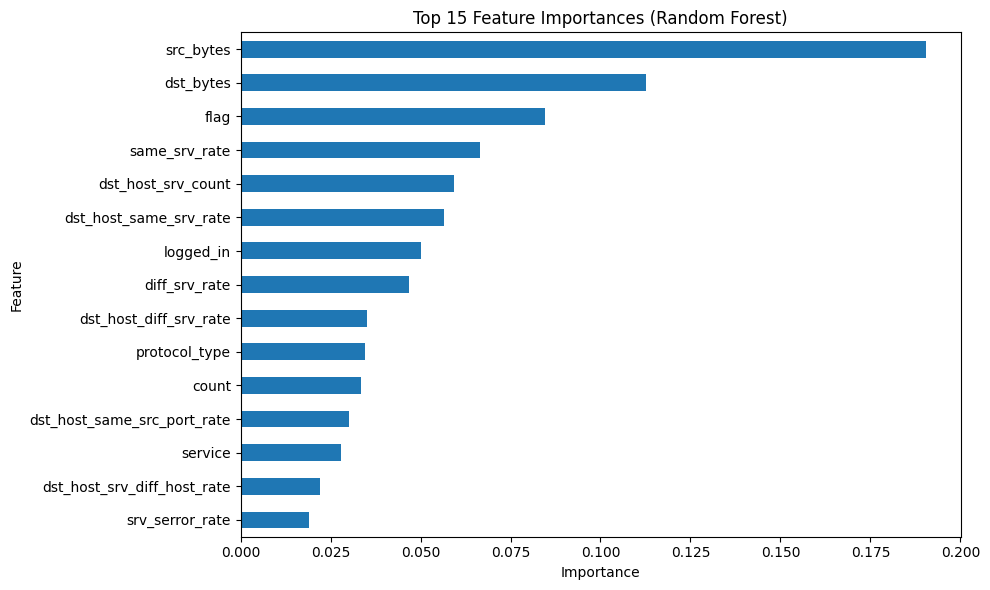

In [36]:
# Feature importance from Random Forest

feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
)

# Top 15 features
top_features = feature_importance.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

top_features.plot(
    kind='barh'
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances (Random Forest)")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [37]:
def plot_confusion_matrix(cm, title):

    plt.figure(figsize=(5,5))

    plt.imshow(cm,
               interpolation='nearest')

    plt.title(title)

    plt.colorbar()

    plt.xticks([0,1], ['Normal','Attack'])
    plt.yticks([0,1], ['Normal','Attack'])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i,j],
                ha='center',
                va='center',
                color='black'
            )

    plt.tight_layout()
    plt.show()

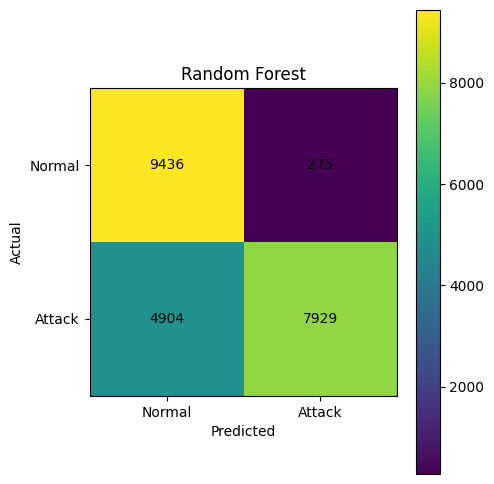

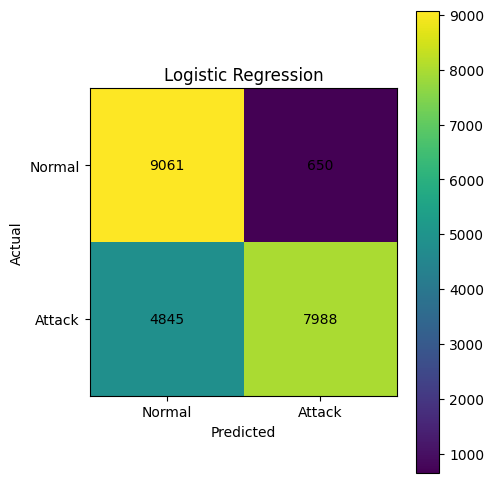

In [38]:
plot_confusion_matrix(cm_rf,
                      "Random Forest")

plot_confusion_matrix(cm_lr,
                      "Logistic Regression")

In [39]:
count_threshold = X_train['count'].quantile(0.95)

src_bytes_threshold = X_train['src_bytes'].quantile(0.95)

srv_count_threshold = X_train['srv_count'].quantile(0.95)

dst_host_srv_count_threshold = (
    X_train['dst_host_srv_count'].quantile(0.95)
)

print(count_threshold)
print(src_bytes_threshold)
print(srv_count_threshold)
print(dst_host_srv_count_threshold)

286.0
1480.0
158.0
255.0


In [40]:
def rule_based_detector(sample):

    score = 0

    if sample['count'] > count_threshold:
        score += 1

    if sample['src_bytes'] > src_bytes_threshold:
        score += 1

    if sample['srv_count'] > srv_count_threshold:
        score += 1

    if sample['dst_host_srv_count'] > dst_host_srv_count_threshold:
        score += 1

    return 1 if score >= 2 else 0

In [41]:
rule_predictions = []

for _, row in X_test.iterrows():

    pred = rule_based_detector(row)

    rule_predictions.append(pred)

print(classification_report(
    y_test,
    rule_predictions
))

              precision    recall  f1-score   support

           0       0.43      0.96      0.59      9711
           1       0.45      0.03      0.05     12833

    accuracy                           0.43     22544
   macro avg       0.44      0.49      0.32     22544
weighted avg       0.44      0.43      0.28     22544



In [42]:
rf_prob = model_rf.predict_proba(X_test)[:,1]
lr_prob = model_lr.predict_proba(X_test_scaled)[:,1]
rule_prob = np.array(rule_predictions)

hybrid_score = (
      0.6*rf_prob
    + 0.3*lr_prob
    + 0.1*rule_prob
)

hybrid_predictions = (
    hybrid_score > 0.5
).astype(int)

              precision    recall  f1-score   support

           0       0.64      0.97      0.77      9711
           1       0.97      0.59      0.73     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.78      0.75     22544
weighted avg       0.83      0.76      0.75     22544



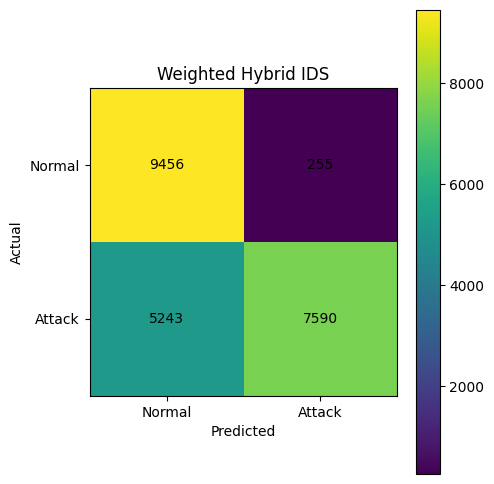

In [43]:
print(classification_report(
    y_test,
    hybrid_predictions
))

cm_hybrid = confusion_matrix(
    y_test,
    hybrid_predictions
)

plot_confusion_matrix(
    cm_hybrid,
    "Weighted Hybrid IDS"
)

In [44]:
confidence = np.maximum(
    hybrid_score,
    1-hybrid_score
)

for i in range(10):

    print(
        "Prediction:",
        "Attack" if hybrid_predictions[i] else "Normal"
    )

    print(
        "Confidence:",
        round(confidence[i]*100,2),
        "%"
    )

    print()

Prediction: Attack
Confidence: 89.91 %

Prediction: Attack
Confidence: 89.68 %

Prediction: Normal
Confidence: 94.54 %

Prediction: Attack
Confidence: 83.9 %

Prediction: Normal
Confidence: 79.53 %

Prediction: Normal
Confidence: 99.84 %

Prediction: Normal
Confidence: 87.18 %

Prediction: Normal
Confidence: 92.92 %

Prediction: Normal
Confidence: 99.83 %

Prediction: Normal
Confidence: 96.16 %



In [50]:
import shap
explainer = shap.TreeExplainer(model_rf)
sample = X_test.sample(n = 500, random_state = 42)
shap_values = explainer(sample)

shap_attack = shap.Explanation(
    values = shap_values.values[:,:,1],
    base_values = shap_values.base_values[:,1],
    data = shap_values.data,
    feature_names = shap_values.feature_names
)


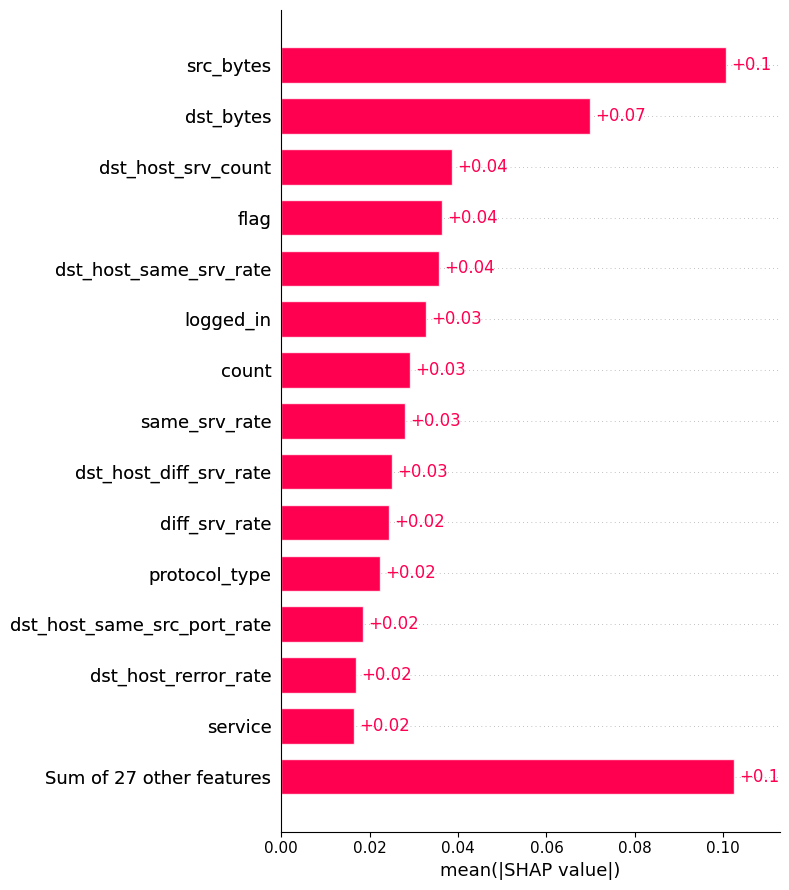

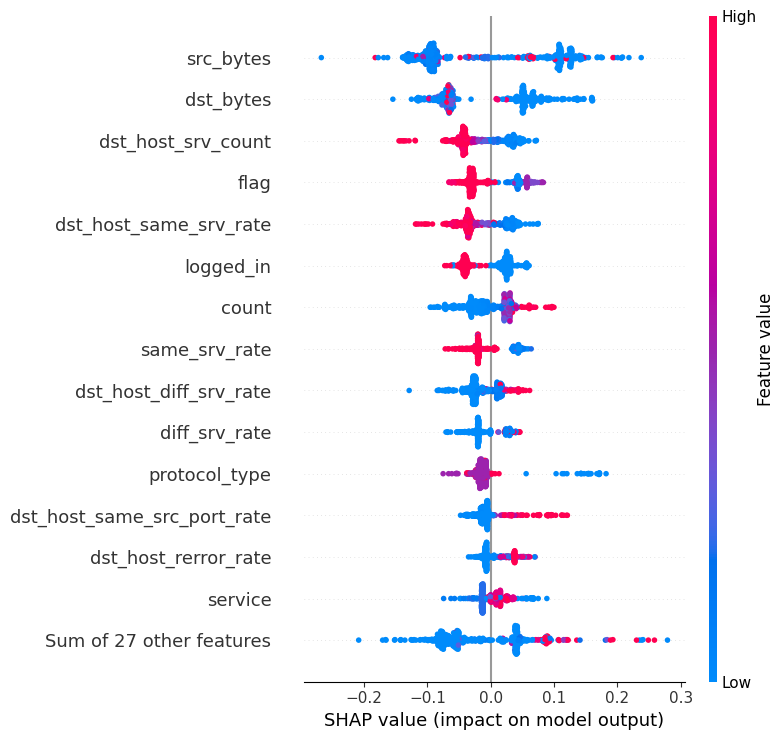

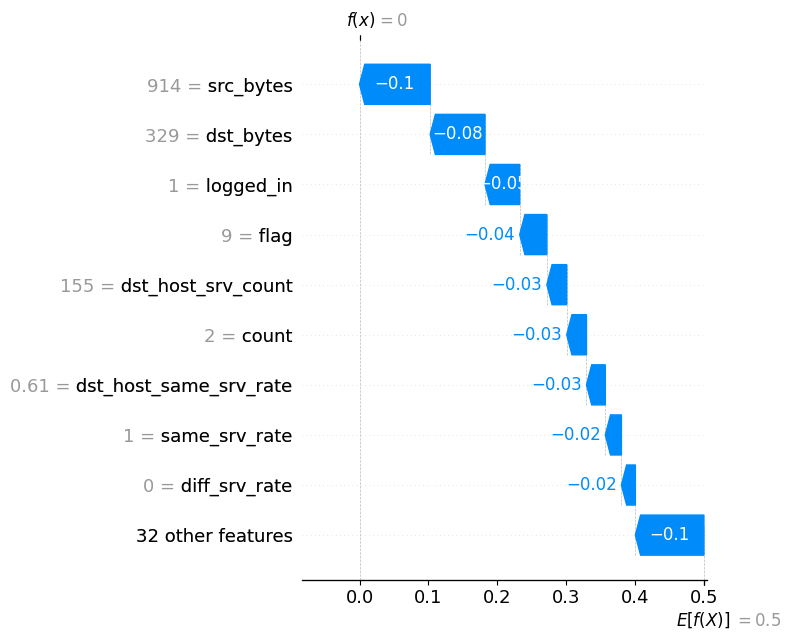

In [51]:
shap.plots.bar(shap_attack, max_display = 15, show=False)
plt.tight_layout()
plt.savefig("plots/shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

shap.plots.beeswarm(shap_attack, max_display =15, show=False)
plt.tight_layout()
plt.savefig("plots/shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

shap.plots.waterfall(shap_attack[0], show=False)
plt.tight_layout()
plt.savefig("plots/shap_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
print(X_train.shape)
print(X_test.shape)
print(sample.shape)
print(len(X_train.columns))
print(len(sample.columns))

(125973, 41)
(22544, 41)
(500, 41)
41
41


In [47]:
print(shap_values.values.shape)
print(shap_values.feature_names)
print(len(shap_values.feature_names))

(500, 41, 2)
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
41


In [48]:
print(shap.__version__)

0.52.0


In [ ]:
# ================= ERROR ANALYSIS =================

results = X_test.copy()

results["Actual"] = y_test.values
results["Prediction"] = hybrid_predictions
results["Confidence"] = confidence

results["Outcome"] = "Correct"

results.loc[
    (results["Actual"] == 0) &
    (results["Prediction"] == 1),
    "Outcome"
] = "False Positive"

results.loc[
    (results["Actual"] == 1) &
    (results["Prediction"] == 0),
    "Outcome"
] = "False Negative"